# Weekly demand remains heterogeneous

Weekly aggregation reduces the sparsity problem seen at the daily product-store grain, but it does **not** turn the data into one homogeneous forecasting problem. Product-store series still split into smooth, erratic, intermittent, and lumpy demand patterns.

This matters for baseline and model design: a single forecasting method is unlikely to be equally appropriate for all product-store series. Smooth and erratic series can be handled with regular time-series baselines, while intermittent and lumpy series need sparse-demand baselines or two-stage approaches.

In [1]:
from pathlib import Path
import os

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import duckdb
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 7)

DATA_DIR_CANDIDATES = [
    Path("../../data/processed/transactions_dst_over_weeks"),
    Path("../data/processed/transactions_dst_over_weeks"),
    Path("data/processed/transactions_dst_over_weeks"),
]
DATA_DIR = next((path for path in DATA_DIR_CANDIDATES if path.exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError(
        "Could not find data/processed/transactions_dst_over_weeks. "
        "Run src/data/preparation/distribute_sales_over_active_weeks.py first."
    )

parquet_glob = str(DATA_DIR / "*.parquet")
print(f"Using weekly data from {DATA_DIR}")

Using weekly data from ../../data/processed/transactions_dst_over_weeks


## Example selection

The four examples below are selected to be representative and comparable:

- one product-store series from each demand class;
- `active_weeks >= 100`;
- ADI and CV² close to the class median;
- stable unit metadata within the series (`ARTIKEL_INHALT`, `VERKAUFSEINHEIT`, `GEWICHTSARTIKEL` each have one value);
- gram-denominated articles only;
- `GEWICHTSARTIKEL = 0` and `VERKAUFSEINHEIT = "St"` for unit comparability.

The notebook first searches for a **single gram-denominated article** that appears in all four demand classes across different stores. In the current data this is possible: the selected examples all use `Goldmarie Schinkenwurst`, `ARTIKEL_INHALT = 200 Gramm`. If that condition fails on another data version, the code falls back to the closest gram-denominated example per class.

In [2]:
GROUP_COLS = ["ARTIKEL_ID", "MARKT_ID"]
DEMAND_COL = "ABVERKAUFTE_MENGE_KG"
MIN_DEMAND_WEEKS = 10
MIN_ACTIVE_WEEKS = 100
ADI_CUTOFF = 1.32
CV2_CUTOFF = 0.49
CLASS_ORDER = ["smooth", "erratic", "intermittent", "lumpy"]
CLASS_PALETTE = {
    "smooth": "#2a9d8f",
    "erratic": "#e9c46a",
    "intermittent": "#457b9d",
    "lumpy": "#d62828",
}

metrics_query = f"""
WITH period_data AS (
    SELECT
        ARTIKEL_ID,
        MARKT_ID,
        CAST(DATE AS DATE) AS week_start,
        SUM(CAST(COALESCE({DEMAND_COL}, 0) AS DOUBLE)) AS demand,
        MIN(ARTIKEL_BEZ) AS ARTIKEL_BEZ,
        MIN(ARTIKEL_INHALT) AS ARTIKEL_INHALT,
        MIN(VERKAUFSEINHEIT) AS VERKAUFSEINHEIT,
        MIN(GEWICHTSARTIKEL) AS GEWICHTSARTIKEL
    FROM read_parquet(?)
    GROUP BY ARTIKEL_ID, MARKT_ID, week_start
), series AS (
    SELECT
        ARTIKEL_ID,
        MARKT_ID,
        COUNT(*) AS active_weeks,
        SUM(CASE WHEN demand > 0 THEN 1 ELSE 0 END) AS demand_weeks,
        SUM(demand) AS total_demand,
        AVG(CASE WHEN demand > 0 THEN demand END) AS mean_nonzero_demand,
        VAR_SAMP(CASE WHEN demand > 0 THEN demand END) AS var_nonzero_demand,
        MIN(week_start) AS first_active_week,
        MAX(week_start) AS last_active_week,
        MIN(ARTIKEL_BEZ) AS ARTIKEL_BEZ,
        MIN(ARTIKEL_INHALT) AS ARTIKEL_INHALT,
        MIN(VERKAUFSEINHEIT) AS VERKAUFSEINHEIT,
        MIN(GEWICHTSARTIKEL) AS GEWICHTSARTIKEL,
        COUNT(DISTINCT ARTIKEL_INHALT) AS n_artikel_inhalt,
        COUNT(DISTINCT VERKAUFSEINHEIT) AS n_verkaufseinheit,
        COUNT(DISTINCT GEWICHTSARTIKEL) AS n_gewichtsartikel
    FROM period_data
    GROUP BY ARTIKEL_ID, MARKT_ID
)
SELECT
    *,
    active_weeks / NULLIF(demand_weeks, 0) AS ADI,
    CASE
        WHEN demand_weeks > 1 AND mean_nonzero_demand > 0
            THEN var_nonzero_demand / (mean_nonzero_demand * mean_nonzero_demand)
        WHEN demand_weeks = 1 THEN 0.0
        ELSE NULL
    END AS CV2
FROM series
WHERE demand_weeks >= {MIN_DEMAND_WEEKS}
"""

con = duckdb.connect()
con.execute("PRAGMA threads=4")
series_metrics = con.execute(metrics_query, [parquet_glob]).fetchdf()

conditions = [
    (series_metrics["ADI"] < ADI_CUTOFF) & (series_metrics["CV2"] < CV2_CUTOFF),
    (series_metrics["ADI"] < ADI_CUTOFF) & (series_metrics["CV2"] >= CV2_CUTOFF),
    (series_metrics["ADI"] >= ADI_CUTOFF) & (series_metrics["CV2"] < CV2_CUTOFF),
    (series_metrics["ADI"] >= ADI_CUTOFF) & (series_metrics["CV2"] >= CV2_CUTOFF),
]
choices = ["smooth", "erratic", "intermittent", "lumpy"]

series_classification = series_metrics.assign(
    demand_class=np.select(conditions, choices, default="unclassified")
)
series_classification = series_classification[
    series_classification["demand_class"].isin(CLASS_ORDER)
].copy()

class_medians = (
    series_classification
    .groupby("demand_class", observed=True)[["ADI", "CV2"]]
    .median()
    .rename(columns={"ADI": "class_median_ADI", "CV2": "class_median_CV2"})
)

class_summary = (
    series_classification
    .groupby("demand_class", observed=True)
    .agg(
        series=("ARTIKEL_ID", "size"),
        median_ADI=("ADI", "median"),
        median_CV2=("CV2", "median"),
        median_active_weeks=("active_weeks", "median"),
        median_demand_weeks=("demand_weeks", "median"),
    )
    .reindex(CLASS_ORDER)
)
class_summary["series_share_%"] = 100 * class_summary["series"] / class_summary["series"].sum()
class_summary.round(2)

,series,median_ADI,median_CV2,median_active_weeks,median_demand_weeks,series_share_%
demand_class,,,,,,
smooth,37056,1.03,0.30,193.0,176.0,20.19
erratic,18682,1.11,0.70,258.0,206.0,10.18
intermittent,52560,3.35,0.36,166.0,29.0,28.63
lumpy,75258,3.53,0.77,204.0,38.0,41.00


In [3]:
eligible = series_classification[
    (series_classification["active_weeks"] >= MIN_ACTIVE_WEEKS)
    & (series_classification["n_artikel_inhalt"] == 1)
    & (series_classification["n_verkaufseinheit"] == 1)
    & (series_classification["n_gewichtsartikel"] == 1)
    & (series_classification["GEWICHTSARTIKEL"] == 0)
    & (series_classification["VERKAUFSEINHEIT"] == "St")
    & (series_classification["ARTIKEL_INHALT"].str.contains("Gramm", na=False))
].copy()

scored = eligible.merge(class_medians, on="demand_class", how="left")
scored["median_distance"] = (
    (scored["ADI"] - scored["class_median_ADI"]).abs() / scored["class_median_ADI"].replace(0, np.nan)
    + (scored["CV2"] - scored["class_median_CV2"]).abs() / scored["class_median_CV2"].replace(0, np.nan)
)

best_per_article_class = (
    scored
    .sort_values(["ARTIKEL_ID", "demand_class", "median_distance", "active_weeks"], ascending=[True, True, True, False])
    .groupby(["ARTIKEL_ID", "demand_class"], observed=True)
    .head(1)
)

article_scores = (
    best_per_article_class
    .groupby("ARTIKEL_ID", observed=True)
    .agg(
        n_classes=("demand_class", "nunique"),
        total_distance=("median_distance", "sum"),
        ARTIKEL_BEZ=("ARTIKEL_BEZ", "first"),
        ARTIKEL_INHALT=("ARTIKEL_INHALT", "first"),
    )
    .loc[lambda df: df["n_classes"].eq(len(CLASS_ORDER))]
    .sort_values("total_distance")
)

if not article_scores.empty:
    selected_article_id = article_scores.index[0]
    selection_note = "same gram-denominated article across four stores"
    example_series = (
        best_per_article_class[best_per_article_class["ARTIKEL_ID"] == selected_article_id]
        .set_index("demand_class")
        .loc[CLASS_ORDER]
        .reset_index()
    )
else:
    selection_note = "closest gram-denominated series per class"
    example_series = (
        scored
        .sort_values(["demand_class", "median_distance", "active_weeks"], ascending=[True, True, False])
        .groupby("demand_class", observed=True)
        .head(1)
        .set_index("demand_class")
        .loc[CLASS_ORDER]
        .reset_index()
    )

example_series = example_series.copy()
example_series["store_label"] = [f"Store {chr(65 + i)}" for i in range(len(example_series))]

example_display_cols = [
    "demand_class", "store_label", "ARTIKEL_BEZ", "ARTIKEL_INHALT",
    "VERKAUFSEINHEIT", "GEWICHTSARTIKEL", "active_weeks", "demand_weeks",
    "ADI", "class_median_ADI", "CV2", "class_median_CV2", "median_distance",
]

print(f"Selection: {selection_note}")
example_series[example_display_cols].round({
    "ADI": 2,
    "class_median_ADI": 2,
    "CV2": 2,
    "class_median_CV2": 2,
    "median_distance": 3,
})

Selection: same gram-denominated article across four stores


,demand_class,store_label,ARTIKEL_BEZ,ARTIKEL_INHALT,VERKAUFSEINHEIT,GEWICHTSARTIKEL,active_weeks,demand_weeks,ADI,class_median_ADI,CV2,class_median_CV2,median_distance
0,smooth,Store A,HofWerte Hofstreich Delikatess,150 Gramm,St,0,142,137.0,1.04,1.03,0.31,0.30,0.031
1,erratic,Store B,HofWerte Hofstreich Delikatess,150 Gramm,St,0,140,125.0,1.12,1.11,0.65,0.70,0.084
2,intermittent,Store C,HofWerte Hofstreich Delikatess,150 Gramm,St,0,141,43.0,3.28,3.35,0.31,0.36,0.146
3,lumpy,Store D,HofWerte Hofstreich Delikatess,150 Gramm,St,0,127,38.0,3.34,3.53,0.80,0.77,0.090


## Four representative weekly series

The examples are now more comparable than before: they are the same gram-denominated article observed in four different stores. The store labels are anonymized in the plot as `Store A`, `Store B`, `Store C`, and `Store D` to keep the storytelling focused on demand shape rather than raw identifiers.

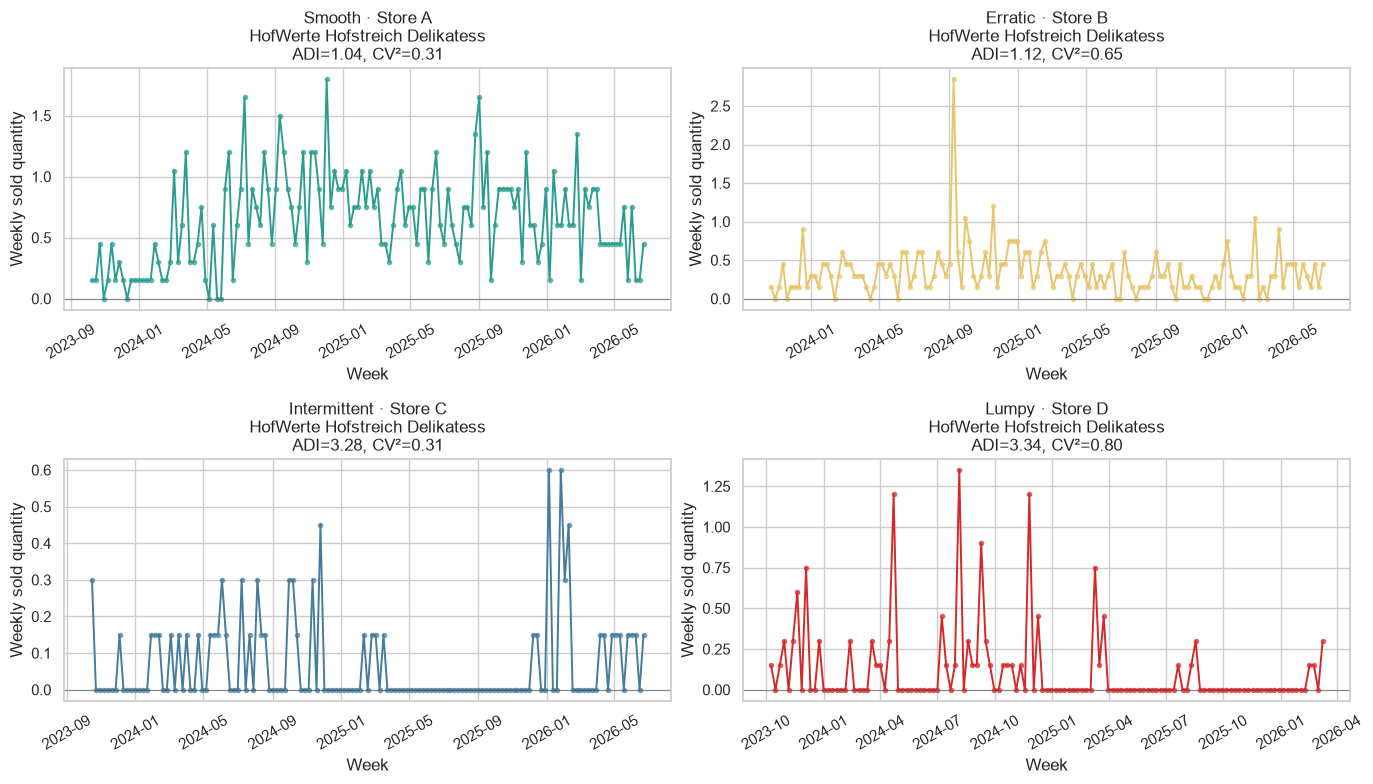

In [4]:
example_keys = example_series[["demand_class", "store_label", "ARTIKEL_ID", "MARKT_ID"]].copy()
con.register("example_keys", example_keys)

examples_query = f"""
SELECT
    k.demand_class,
    k.store_label,
    w.ARTIKEL_ID,
    w.MARKT_ID,
    CAST(w.DATE AS DATE) AS week_start,
    CAST(COALESCE(w.{DEMAND_COL}, 0) AS DOUBLE) AS demand
FROM read_parquet(?) AS w
JOIN example_keys AS k
    ON w.ARTIKEL_ID = k.ARTIKEL_ID
    AND w.MARKT_ID = k.MARKT_ID
ORDER BY k.demand_class, k.store_label, week_start
"""
example_ts = con.execute(examples_query, [parquet_glob]).fetchdf()

plot_data = example_ts.merge(
    example_series[[
        "demand_class", "store_label", "ARTIKEL_ID", "MARKT_ID", "ARTIKEL_BEZ",
        "ARTIKEL_INHALT", "ADI", "CV2", "active_weeks", "demand_weeks"
    ]],
    on=["demand_class", "store_label", "ARTIKEL_ID", "MARKT_ID"],
    how="left",
)

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=False)
axes = axes.ravel()

for ax, demand_class in zip(axes, CLASS_ORDER):
    subset = plot_data[plot_data["demand_class"] == demand_class].sort_values("week_start")
    meta = subset.iloc[0]
    color = CLASS_PALETTE[demand_class]
    ax.plot(subset["week_start"], subset["demand"], color=color, linewidth=1.4)
    ax.scatter(subset["week_start"], subset["demand"], color=color, s=9, alpha=0.65)
    ax.axhline(0, color="#444444", linewidth=0.8, alpha=0.5)
    ax.set_title(
        f"{demand_class.capitalize()} · {meta['store_label']}\n"
        f"{meta['ARTIKEL_BEZ']}\n"
        f"ADI={meta['ADI']:.2f}, CV²={meta['CV2']:.2f}"
    )
    ax.set_xlabel("Week")
    ax.set_ylabel("Weekly sold quantity")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()

## Interpretation

The weekly aggregation makes the data more usable for baseline modeling, but the four plots show that the demand-generating process is still heterogeneous even for the same product:

- **Smooth**: frequent demand with comparatively stable non-zero quantities.
- **Erratic**: frequent demand but volatile quantities.
- **Intermittent**: many no-sale weeks, with relatively stable non-zero quantities when sales occur.
- **Lumpy**: many no-sale weeks and volatile non-zero quantities.

This supports implementing and evaluating different model families by demand pattern instead of forcing one baseline or one forecasting model across all product-store series.